In [1]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('sales_data.csv')

In [2]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18.0,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,NaN,17.0,NaN,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30.0,Food,NaN,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,NaN,2167.94,39.0,Clothing,NaN,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,NaN,3750.20,NaN,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             998 non-null    object 
 3   Region                996 non-null    object 
 4   Sales_Amount          996 non-null    float64
 5   Quantity_Sold         997 non-null    float64
 6   Product_Category      995 non-null    object 
 7   Unit_Cost             997 non-null    float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 109.5+ KB


In [4]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               2
Region                  4
Sales_Amount            4
Quantity_Sold           3
Product_Category        5
Unit_Cost               3
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [5]:
# for text values
df['Product_Category'] = df['Product_Category'].fillna('Uncategorized')
# Fill missing Reps and Regions with 'Unknown'
df['Sales_Rep'] = df['Sales_Rep'].fillna('Unknown')
df['Region'] = df['Region'].fillna('Unknown')

In [8]:
# Filling Sales_Amount with Median
df['Sales_Amount'] = df['Sales_Amount'].fillna(df['Sales_Amount'].median())

# Filling Quantity with 0 (assuming no sale if missing) or Median
df['Quantity_Sold'] = df['Quantity_Sold'].fillna(df['Quantity_Sold'].median())
df['Unit_Cost'] = df['Unit_Cost'].fillna(df['Unit_Cost'].median())

print("Data Cleaned Successfully!")

Data Cleaned Successfully!


In [9]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

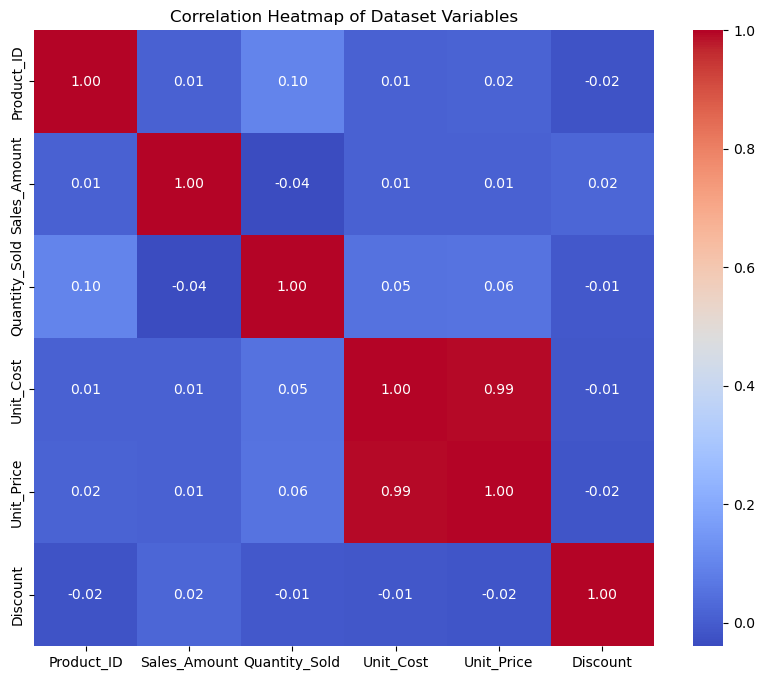

In [10]:
#heatmap correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Dataset Variables')
plt.show()

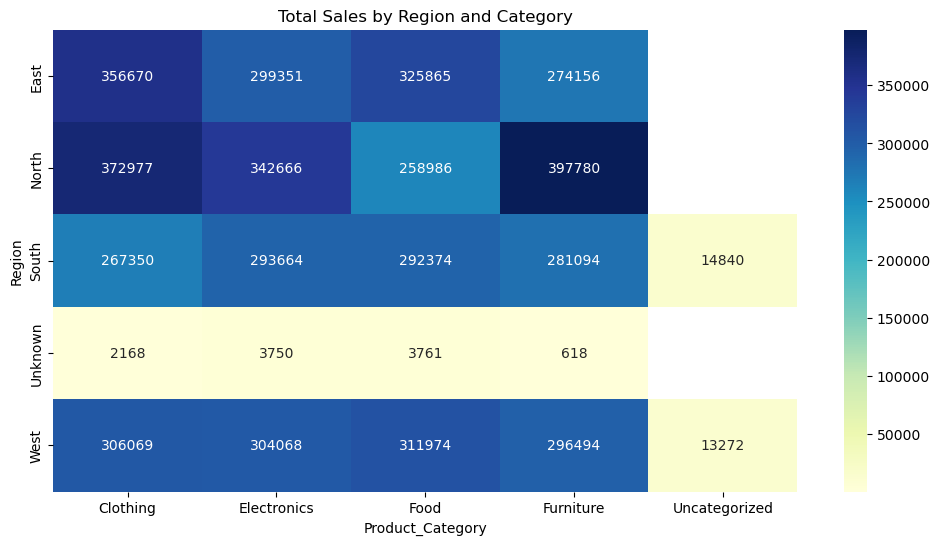

In [11]:
#catagorical heatmap
pivot_table = df.pivot_table(index='Region', columns='Product_Category', values='Sales_Amount', aggfunc='sum')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.0f')
plt.title('Total Sales by Region and Category')
plt.show()

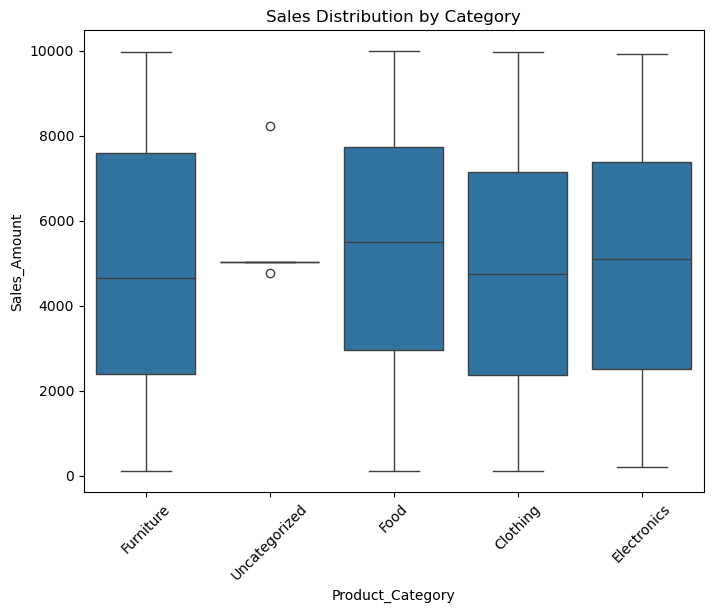

In [12]:
#Distribution graphs 
plt.figure(figsize=(8, 6))
sns.boxplot(x='Product_Category', y='Sales_Amount', data=df)
plt.xticks(rotation=45)
plt.title('Sales Distribution by Category')
plt.show()

C:\Users\Zeeshan\AppData\Local\Temp\ipykernel_14808\1174117830.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Quantity_Sold', y='Product_Category', data=cat_performance, palette='viridis')


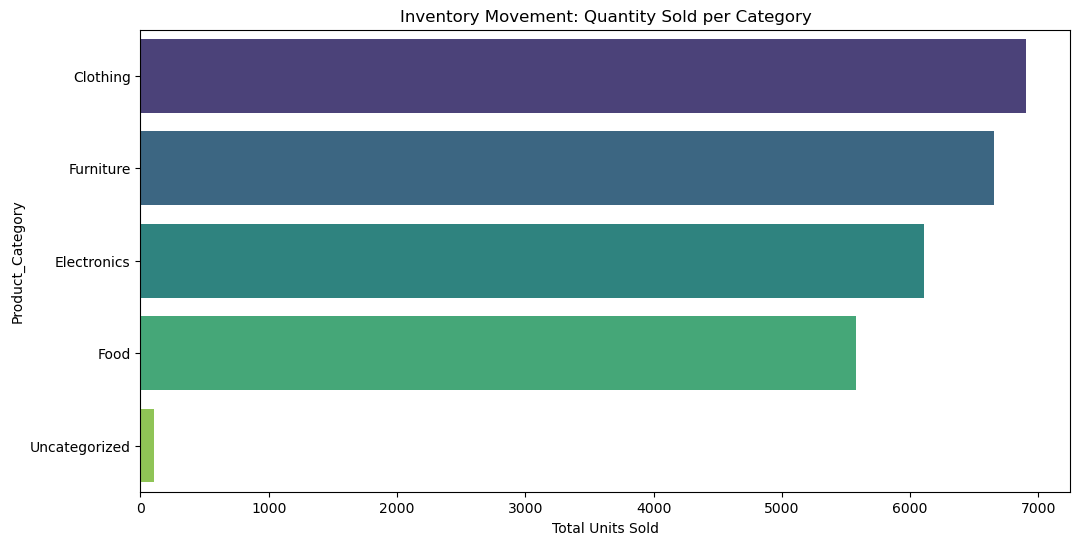

In [13]:
#bar charts 
cat_performance = df.groupby('Product_Category')['Quantity_Sold'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Quantity_Sold', y='Product_Category', data=cat_performance, palette='viridis')
plt.title('Inventory Movement: Quantity Sold per Category')
plt.xlabel('Total Units Sold')
plt.show()

In [15]:
print("EDA PERFORMED")


      

EDA PERFORMED
